# Data exploration of collision_dataset.txt
An exploration of the dataset generated by Benjamin Vollebregt using CTC simulations for two colliding $H_2$ molecules.

## Info

### Dataset explanation

collision_dataset.txt contains 10.000 the translational and rotational energies of two colliding particles for 10.000 simulations.

There are 7 columns containing the following:

'b' = impact parameter

'Etr' = precollisional translational kinetic energy of particle 1 + translational kinetic energy of particle 2 [in Kelvin]. Both particles start with equal velocity so $Etr_A = Etr_B = 0.5 Etr$.

'Er1' = precollisional rotational kinetic energy of particle 1

'Er2' = precollisional rotational kinetic energy of particle 2

'Etrp'= postcollisional translational kinetic energy of particle 1 + translational kinetic energy of particle 2 [in Kelvin]

'Er1p' = postcollisional rotational kinetic energy of particle 1

'Er2p' = postcollisional rotational kinetic energy of particle 2

### Initial inspection

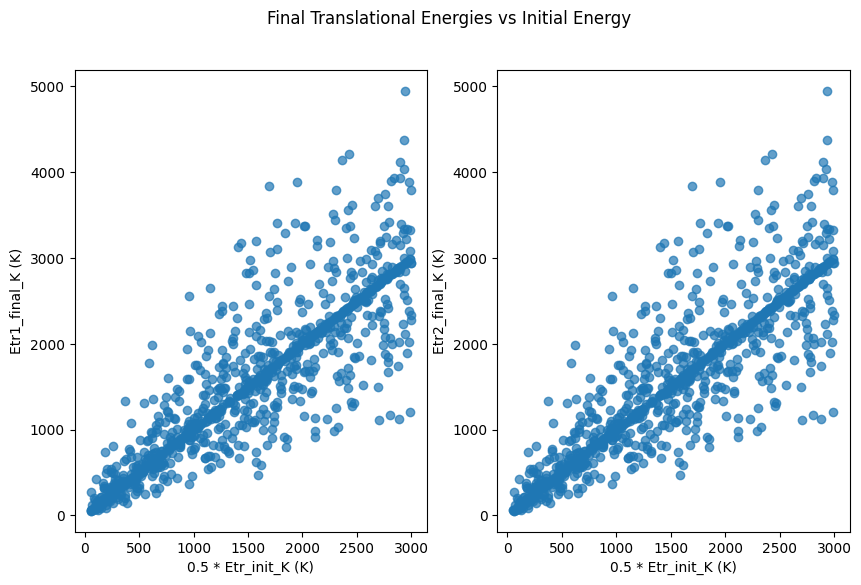

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


DATA_FILE = "CTC_simulation_results.csv"

df = pd.read_csv(DATA_FILE)

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].scatter(0.5 * df["Etr_init_K"], df["Etr1_final_K"], alpha=0.7)
ax[1].scatter(0.5 * df["Etr_init_K"], df["Etr2_final_K"], alpha=0.7)
ax[0].set_xlabel("0.5 * Etr_init_K (K)")
ax[0].set_ylabel("Etr1_final_K (K)")
ax[1].set_xlabel("0.5 * Etr_init_K (K)")
ax[1].set_ylabel("Etr2_final_K (K)")
plt.suptitle("Final Translational Energies vs Initial Energy")
plt.show()

## Data distribution
Plot histograms of pre- and post-collisional data to visualize the data distributions

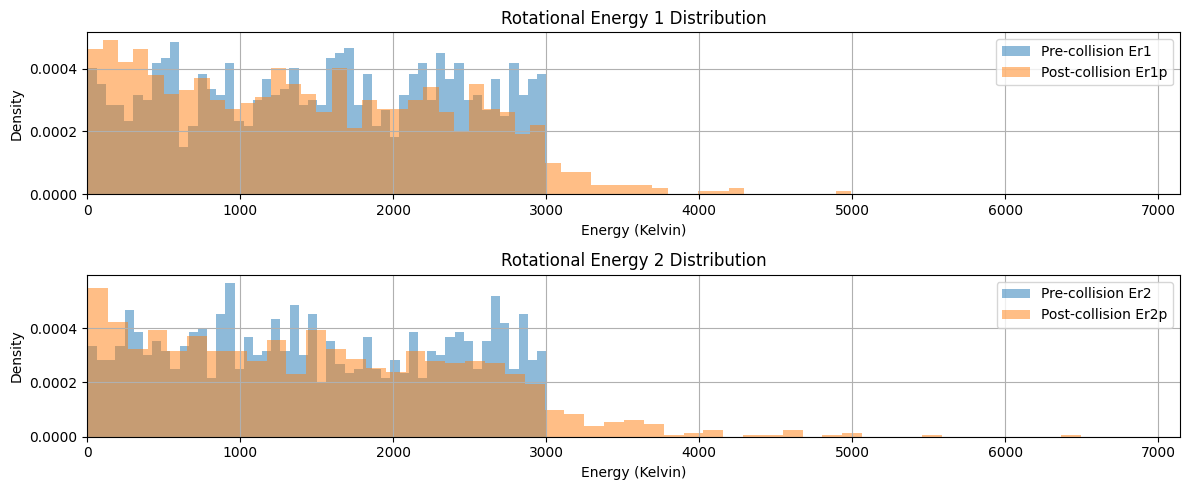

In [15]:
# Plot histogram of pre- and post-collision energies
# Rotational energies
fig, ax = plt.subplots(2,1)
fig.set_size_inches(12, 5)
xmax = max(df['Er1_init_K'].max(), df['Er1_final_K'].max(), df['Er2_init_K'].max(), df['Er2_final_K'].max())*1.1

ax[0].hist(df['Er1_init_K'], bins=50, alpha=0.5, label='Pre-collision Er1', density=True)
ax[0].hist(df['Er1_final_K'], bins=50, alpha=0.5, label='Post-collision Er1p', density=True)
ax[0].set_xlim(0, xmax)
ax[0].set_title('Rotational Energy 1 Distribution')
ax[0].set_xlabel('Energy (Kelvin)')
ax[0].set_ylabel('Density')
ax[0].legend()
ax[0].grid()

ax[1].hist(df['Er2_init_K'], bins=50, alpha=0.5, label='Pre-collision Er2', density=True)
ax[1].hist(df['Er2_final_K'], bins=50, alpha=0.5, label='Post-collision Er2p', density=True)
ax[1].set_xlim(0, xmax)
ax[1].set_title('Rotational Energy 2 Distribution')
ax[1].set_xlabel('Energy (Kelvin)')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

KeyError: 'Etr_final_K'

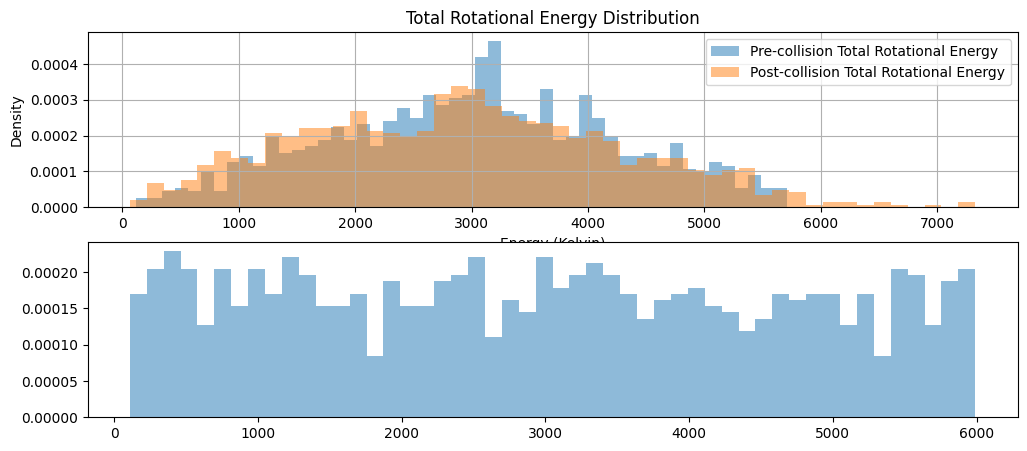

In [ ]:
# Total rotational energy and translational energy
fig, ax = plt.subplots(2,1)
fig.set_size_inches(12, 5)
ax[0].hist(df['Er1_init_K'] + df['Er2_init_K'], bins=50, alpha=0.5, label='Pre-collision Total Rotational Energy', density=True)
ax[0].hist(df['Er1_final_K'] + df['Er2_final_K'], bins=50, alpha=0.5, label='Post-collision Total Rotational Energy', density=True)
ax[0].set_title('Total Rotational Energy Distribution')
ax[0].set_xlabel('Energy (Kelvin)')
ax[0].set_ylabel('Density')
ax[0].legend()
ax[0].grid()

ax[1].hist(df['Etr_init_K'], bins=50, alpha=0.5, label='Pre-collision Translational Energy', density=True)
ax[1].hist(df['Etr1_final_K'] + df['Etr2_final_K'], bins=50, alpha=0.5, label='Post-collision Translational Energy', density=True)
ax[1].set_title('Translational Energy Distribution')
ax[1].set_xlabel('Energy (Kelvin)')
ax[1].set_ylabel('Density')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

The above plot shows clearly that the precollisional data is initialized in the [0K,3000K] energy interval. Post collision the data is less centered around the mean and has a longer tail meaning that the distribution of energies tends to be more spread out after the collision because the randomness of the collision process pushes the distribution toward a normal distribution.